### **Agrupación / Clustering**

**Importar librerías**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

**Cargar CSV**

In [2]:
url = "https://raw.githubusercontent.com/MarvinAntillon97/Parcial4_AntillonMarvin_2533222022/refs/heads/main/Archivos/clave_E_agrupacion.csv"

df = pd.read_csv(url)

df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,E-R0096,39,986,7.83,99.00,8.08,2,24
1,E-R0092,41,905,5.52,82.98,8.07,2,23
2,E-R0079,34,1109,7.17,65.25,8.46,0,13
3,E-R0019,32,618,2.57,25.75,5.09,12,21
4,E-R0174,49,1592,8.08,172.04,6.55,0,28


**Revisar estructura del dataset**

In [3]:
print(df.shape)

print(df.columns)

print(df.info())

(246, 8)
Index(['registro_id', 'edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio',
       'satisfaccion', 'reclamos', 'antiguedad_meses'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       246 non-null    object 
 1   edad              246 non-null    int64  
 2   ingresos          246 non-null    int64  
 3   frecuencia_uso    246 non-null    float64
 4   gasto_promedio    246 non-null    float64
 5   satisfaccion      245 non-null    float64
 6   reclamos          246 non-null    int64  
 7   antiguedad_meses  246 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 15.5+ KB
None


**Revisar nulos y duplicados**

In [4]:
print(df.isnull().sum())

print(df.duplicated().sum())

registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64
0


**Seleccionar variables para clustering**

In [8]:
variables_cluster = [
    'edad',
    'ingresos',
    'frecuencia_uso',
    'gasto_promedio',
    'satisfaccion',
    'reclamos',
    'antiguedad_meses'
]

X = df[variables_cluster]

X.head()

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,39,986,7.83,99.00,8.08,2,24
1,41,905,5.52,82.98,8.07,2,23
2,34,1109,7.17,65.25,8.46,0,13
3,32,618,2.57,25.75,5.09,12,21
4,49,1592,8.08,172.04,6.55,0,28


**Escalar datos**

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Método del codo**

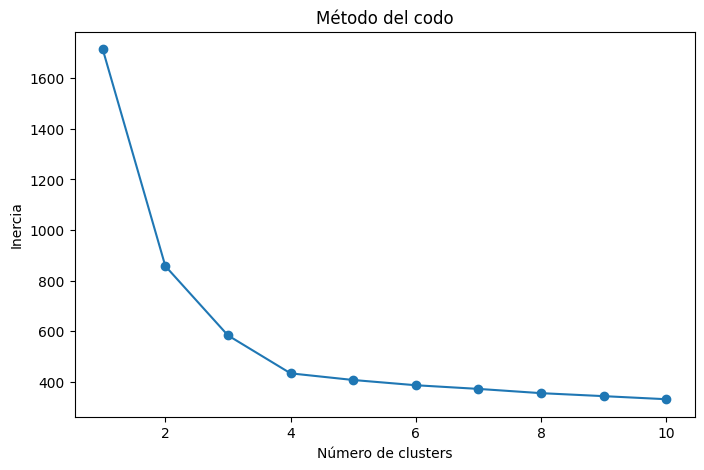

In [12]:
import numpy as np

inercias = []

# Remove rows with NaN values from X_scaled before fitting KMeans
X_scaled_clean = X_scaled[~np.isnan(X_scaled).any(axis=1)]

for k in range(1, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled_clean) # Fit on the cleaned data

    inercias.append(modelo.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inercias, marker='o')

plt.xlabel('Número de clusters')
plt.ylabel('Inercia')

plt.title('Método del codo')

plt.show()

**Aplicar K-Means con 4 clusters**

In [14]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Get the boolean mask that indicates which rows in the original X (and thus df)
# were kept after removing NaNs. This aligns with X_scaled_clean.
clean_row_mask = ~X.isnull().any(axis=1)

# Apply KMeans and get predictions for the cleaned data
cluster_labels = kmeans.fit_predict(X_scaled_clean)

# Assign the cluster labels to the original DataFrame,
# but only for the rows that were included in the clustering.
df.loc[clean_row_mask, 'cluster'] = cluster_labels

df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,E-R0096,39,986,7.83,99.00,8.08,2,24,0.0
1,E-R0092,41,905,5.52,82.98,8.07,2,23,0.0
2,E-R0079,34,1109,7.17,65.25,8.46,0,13,0.0
3,E-R0019,32,618,2.57,25.75,5.09,12,21,2.0
4,E-R0174,49,1592,8.08,172.04,6.55,0,28,1.0


**Ver cantidad de registros por cluster**

In [15]:
print(df['cluster'].value_counts())

cluster
0.0    67
3.0    63
1.0    61
2.0    54
Name: count, dtype: int64


**Promedio por cluster**

In [16]:
cluster_analysis = df.groupby('cluster')[
    variables_cluster
].mean()

cluster_analysis.round(2)

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
cluster,,,,,,,
0.0,36.12,1020.84,6.19,85.63,8.12,1.25,15.99
1.0,49.67,1628.98,8.90,149.44,8.76,0.66,35.00
2.0,41.41,837.02,3.85,60.61,4.54,5.24,12.44
3.0,26.06,630.21,2.00,32.47,6.05,3.08,7.21
